
# ⚠️ (collab only) Enable GPU Acceleration

To run the deep learning models, you'd better enable the GPU runtime.

Go to the top menu: **Runtime -> Change runtime type**.

Under **Hardware accelerator**, select **T4 GPU** (or any available GPU).

Click **Save**.

Check the top-right corner to ensure it says **RAM/Disk** with a green checkmark.

# ⚠️ If you use your local computer

Prepare followings:
- Git clone (SAPSAL)
- Setup your python environments
- Install necessary packages


# 1. Enviornment Setup
- localreg
- numba
- ray
- gpuutil (only for CUDA GPU users)
- for collab: mpld3 (not necessary) for figure zoom in

In [1]:
# [Step 1] Install necessary python packages
# See README
# Note: Basic packages like torch, numpy, and astropy are pre-installed in Colab.
# from google.colab import output
# output.enable_custom_widget_manager()

import importlib
import subprocess
import sys, os
import numpy as np
from time import time
import warnings
warnings.filterwarnings("ignore", category=SyntaxWarning)

def install_if_missing(package, install_cmd=None):
    try:
        importlib.import_module(package)
        print(f"✅ '{package}' is already installed.")
    except ImportError:
        print(f"📦 Installing '{package}'... This may take a moment.")
        cmd = install_cmd if install_cmd else [sys.executable, "-m", "pip", "install", package]
        subprocess.check_call(cmd + ["-q"])
        print(f"Successfully installed '{package}'!")

# Install: localreg, numba, ray
install_if_missing("localreg")
install_if_missing("numba")
try:
    importlib.import_module("ray")
    print("✅ 'ray' is already installed.")
except ImportError:
    print("📦 Installing 'ray[default]'... Please wait.")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", "ray[default]", "-q"])
    print("Successfully installed 'ray'!")

# !pip install -q localreg numba
# !pip install -q -U "ray[default]"

if 'google.colab' in sys.modules:
  print("Some additional pakcages for plotting in this tutorial... (not necessary)")
  install_if_missing("mpld3")
  import mpld3

# %matplotlib widget
import matplotlib.pyplot as plt
plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15
plt.rcParams['axes.labelsize'] = 20

📦 Installing 'localreg'... This may take a moment.
✅ 'numba' is already installed.
📦 Installing 'ray[default]'... Please wait.
Some additional pakcages for plotting in this tutorial... (not necessary)
📦 Installing 'mpld3'... This may take a moment.


In [2]:
# [Pytorch] PyTorch, Torchvision, CUDA is already availabel in collab
# Check GPU
import torch
print(f"Checking Pytorch\n")
print(f"PyTorch Version: {torch.__version__}")
if torch.cuda.is_available():
  print(f"CUDA GPU Available: {torch.cuda.is_available()}")
  print(f"GPU Name: {torch.cuda.get_device_name(0)}")

  # Install gputil for GPU searching: not necessary if you don't use find_gpu_available function
  install_if_missing("gputil")
  # Check GPU memory available
  # Total memory of the device
  total_mem = torch.cuda.get_device_properties(0).total_memory / 1024**2
  used_mem = torch.cuda.memory_allocated(0) / 1024**2
  reserved_mem = torch.cuda.memory_reserved(0) / 1024**2
  print(f"Total GPU Memory: {total_mem:.0f} MiB")
  print(f"Used GPU Memory: {used_mem:.0f} MiB")
  print(f"Free GPU Memory: {(total_mem - reserved_mem):.0f} MiB")

  !nvidia-smi

elif torch.backends.mps.is_available(): # Mac GPU
  if not torch.backends.mps.is_built():
        print("MPS not available because the current PyTorch install was not "
              "built with MPS enabled.")
  else:
    print("MPS available: use 'mps' for device")
else:
  print("GPU not available. Use 'cpu' for device")

Checking Pytorch

PyTorch Version: 2.10.0+cu128
CUDA GPU Available: True
GPU Name: Tesla T4
📦 Installing 'gputil'... This may take a moment.
Total GPU Memory: 14913 MiB
Used GPU Memory: 0 MiB
Free GPU Memory: 14913 MiB
Tue Apr 21 08:09:14 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C  

In [3]:
# [Step 2] Install SAPSAL
IN_COLAB = 'google.colab' in sys.modules
target_dir = 'SAPSAL'
if IN_COLAB:
    print("Running on Google Colab. Setting up environment...")
    base_path = '/content'
    sapsal_path = os.path.join(base_path, target_dir)
    os.chdir(base_path)

    if not os.path.exists(target_dir):
      !git clone https://github.com/kangdaeun/SAPSAL.git {target_dir}
    else:
        # print("SAPSAL folder already exists. Skipping clone.")
        print("🔄 Repository already exists. Pulling the latest updates...")
        os.chdir(sapsal_path)
        !git pull origin master

    os.chdir(sapsal_path)
    if sapsal_path not in sys.path:
        sys.path.append(sapsal_path)


# If using local computer, add the correponding path to SAPSAL
# sapsal_path =

print(f"Current Working Directory: {os.getcwd()}")

Running on Google Colab. Setting up environment...
Cloning into 'SAPSAL'...
remote: Enumerating objects: 757, done.
remote: Counting objects: 100% (107/107), done.
remote: Compressing objects: 100% (90/90), done.
remote: Total 757 (delta 58), reused 57 (delta 17), pack-reused 650 (from 3)
Receiving objects: 100% (757/757), 357.45 MiB | 22.55 MiB/s, done.
Resolving deltas: 100% (468/468), done.
Updating files: 100% (87/87), done.
Current Working Directory: /content/SAPSAL


# 2. Load a network model

In [4]:
import sapsal

In [5]:
# Pre-trained networks avaialble
print("Network codes available:", sapsal.io.AVAILABLE_NET_CODES)
print("Official names:",sapsal.io.NETWORK_OFFICIAL_NAMES)
print("Short names:",sapsal.io.NETWORK_SHORT_NAMES)

Network codes available: ['v1_settl', 'v2_k25', 'v3_vis', 'v3_uv']
Official names: {'v1_settl': 'SAPSAL-v1-Settl', 'v2_k25': 'SAPSAL-v2-K25', 'v3_vis': 'SAPSAL-v3-Vis', 'v3_uv': 'SAPSAL-v3-UV'}
Short names: {'v1_settl': 'Settl-Net', 'v2_k25': 'K25-Net', 'v3_vis': 'Vis-Net', 'v3_uv': 'UV-Net'}


In [6]:
# Select one net-code and load a network model
config = sapsal.io.load_pretrained_network('v3_vis', verbose=True)

config.print_short_setting()
print(f"{config.x_dim} parameters to predict: ", config.x_names)
print(f"{config.y_dim_in} observables needed: ", config.y_names)
if config.prenoise_training:
    print("The network is in Noise-Net mode")
    print("Need 1-sigma fractional error for each y_names component")
print(f"Current device: {config.device}")

Requested network: Vis-Net (code: v3_vis, Official Name: SAPSAL-v3-Vis)
Unzip the network (/content/SAPSAL/sapsal/networks/v3_vis/v3_Vis_Net.pt.zip)... (Only once per network)
Network config loaded successfully.
==================== cINN NETWORK SETTING =================
cINN_config file: config_v3_Vis.py
# of parameters: 9
# of observables: 44
device: cpu
Network in Noise-Net mode
9 parameters to predict:  ['logTeff', 'logG', 'A_V', 'log_veil_r', 'library', 'Tslab', 'log_ne', 'log_tau0', 'log_Fslab']
44 observables needed:  ['R_V', 'f4770', 'f5125', 'f5415', 'f6010', 'f6255', 'f6447.5', 'f6630', 'f6825', 'f7030', 'f7070', 'f7100', 'f7140', 'f7200', 'f7400', 'f7500', 'f7560', 'f7975', 'f8100', 'f8575', 'f8630', 'f8710']
The network is in Noise-Net mode
Need 1-sigma fractional error for each y_names component
Current device: cpu


In [7]:
# Load multiple networks and keep config
config_dic = {}
net_codes = ['v3_vis'] #, 'v3_uv']
for net_code in net_codes:
  config_dic[net_code]={}
  config_dic[net_code]['config'] = sapsal.io.load_pretrained_network(net_code, verbose=True)
  config.print_short_setting()
  print()

Requested network: Vis-Net (code: v3_vis, Official Name: SAPSAL-v3-Vis)
Network config loaded successfully.
==================== cINN NETWORK SETTING =================
cINN_config file: config_v3_Vis.py
# of parameters: 9
# of observables: 44
device: cpu
Network in Noise-Net mode



# 3. Prepare observational data

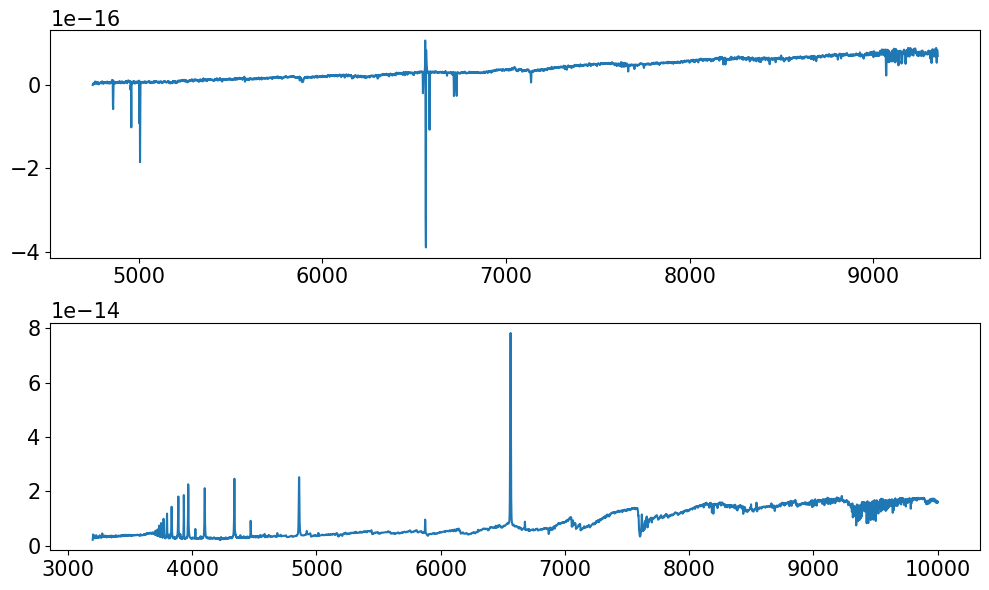

In [8]:
# Read example spectra
import glob
file_dir = sapsal_path + "/examples/"

muse_examples = sorted(glob.glob(file_dir+"Tr14_spec/*.dat")) # one column: flux (erg/s/cm2/A)
wl_muse = np.arange(4750.1572265625, 9351.4072265625, 1.25)
muse_spec_array = []
for file in muse_examples:
  muse_spec_array.append(np.loadtxt(file))
muse_spec_array = np.array(muse_spec_array)

xs_examples = sorted(glob.glob(file_dir+"Lupus_examples/*.txt")) # three columns: wl (A), flux (erg/s/cm2/A), flux error (erg/s/cm2/A)
xs_spec_array = []
xs_err_array = []
for file in xs_examples:
  wl_xshooter, flux, err = np.loadtxt(file, unpack=True)
  xs_spec_array.append(flux)
  xs_err_array.append(err)
xs_spec_array = np.array(xs_spec_array)
xs_err_array = np.array(xs_err_array)

fig, axis = plt.subplots(2,1, figsize=[10, 6], tight_layout=1)
axis[0].plot(wl_muse, muse_spec_array[0] )
axis[1].plot(wl_xshooter, xs_spec_array[0])
# mpld3.display(fig)
# flux: erg/s/cm2/A
# wavelength : A


# 4. Data pre-processing: making network input data



In [9]:
from sapsal import expander as exp

Each network requires different input format:
- SAPSAL-v3s: Vis-Net, UV-Net: uses median flux at each wavelength points: median in +/-10A window
- SAPSAL-v2: K25-Net: use spectra following wl_muse. but some bins are masked and you should exclude them.
- SAPSAL-v1: Settl-Net: use spectra following wl_muse. but some bins are masked and you should exclude them.



In [10]:
# Pre-processing Vis-Net
net_code = 'v3_vis'
config = config_dic[net_code]['config']
print(config.y_names)

# v3 networks only
wl_used = exp.get_wl_used(config.y_names)
print(wl_used)
i_fluxloc = exp.get_flux_loc(config.y_names)
print("index of y_names relevant to flux:", i_fluxloc)

['R_V', 'f4770', 'f5125', 'f5415', 'f6010', 'f6255', 'f6447.5', 'f6630', 'f6825', 'f7030', 'f7070', 'f7100', 'f7140', 'f7200', 'f7400', 'f7500', 'f7560', 'f7975', 'f8100', 'f8575', 'f8630', 'f8710']
[4770.  5125.  5415.  6010.  6255.  6447.5 6630.  6825.  7030.  7070.
 7100.  7140.  7200.  7400.  7500.  7560.  7975.  8100.  8575.  8630.
 8710. ]
index of y_names relevant to flux: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21]


## Input for SAPSAL-v3 networks: Vis-Net
- flux : median flux within +/-10A window
- flux uncertainty: standar deviation within +/-10A window divided by the meidan flux (N/S)
- Rv: Rv value of the cluster, Rv uncertainty: Rv error/Rv

Uncertainty: [0.04545455 0.33463609 0.15982265 0.13344582 0.04856807 0.05794486
 0.0868106  0.02424837 0.02699536 0.04114283 0.04400427 0.02568514
 0.23347844 0.03426902 0.02950822 0.03189616 0.01719483 0.0159392
 0.01913493 0.01528143 0.02074168 0.01759211]


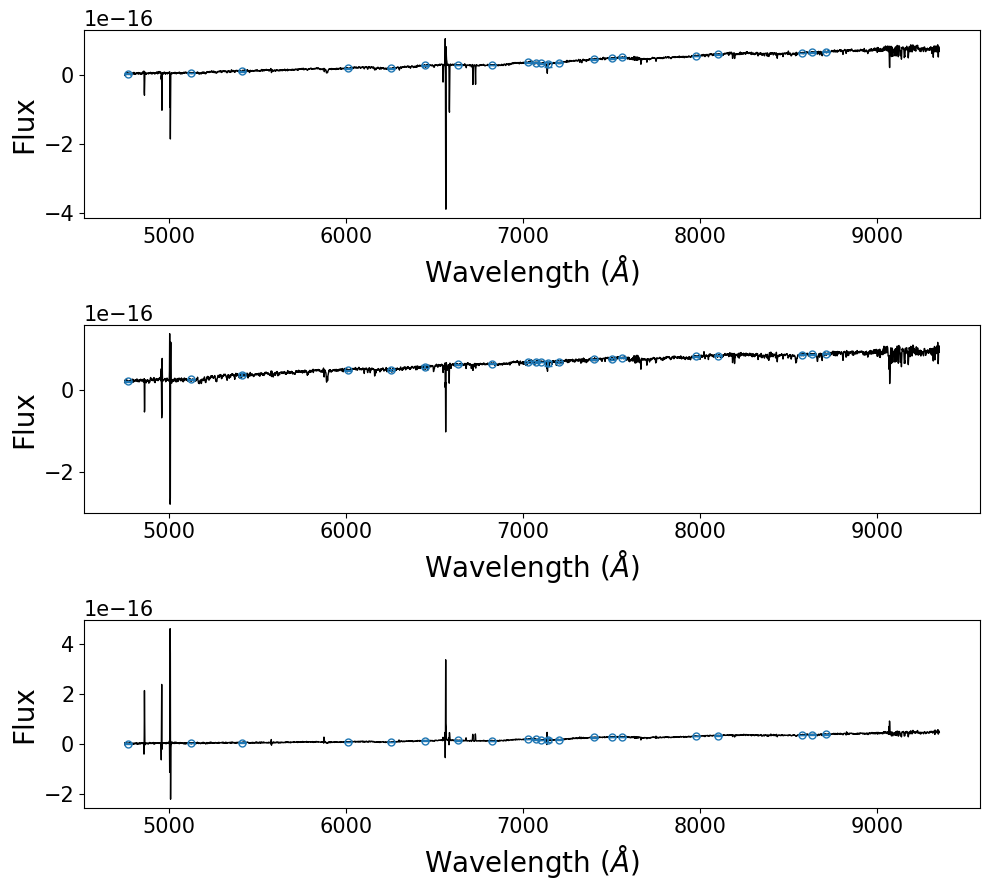

In [11]:
muse_input_obs = np.zeros(shape=(len(muse_spec_array), len(config.y_names)))
muse_input_unc = np.zeros(shape=(len(muse_spec_array), len(config.y_names)))

# Rv data (index=0)
i_Rv = config.y_names.index('R_V')
# for MUSE data (Tr14): Rv = 4.4 +/- 0.2
muse_input_obs[:, i_Rv] = 4.4
muse_input_unc[:, i_Rv] = 0.2/4.4

# Flux data : median and standard deviation/median
# Extract median from +/-10 A window for each wavelength
wl = wl_muse # wavelengths of obs data
dwl = 10
for i, spec in enumerate(muse_spec_array):
    for wl0, yind in zip(wl_used, i_fluxloc):
        id_min = np.abs(wl -(wl0 - dwl)).argmin()
        id_max = np.abs(wl -(wl0 + dwl)).argmin()

        flux = spec[id_min:id_max+1]
        # Recommend: flux > 0
        roi_pos = flux > 0
        median = np.nanmedian(flux[roi_pos])
        std = np.nanstd(flux[roi_pos])

        muse_input_obs[i, yind] = median
        muse_input_unc[i, yind] = std/median


print("Uncertainty:",muse_input_unc[0])

# Check the median values
fig, axis = plt.subplots(3,1, figsize=[10, 9], tight_layout=1)
for i in range(len(muse_spec_array)):
    axis[i].plot(wl_muse, muse_spec_array[i], lw=1, color='k',  label="Observed spectrum" )
    axis[i].errorbar(wl_used, muse_input_obs[i, i_fluxloc], yerr=muse_input_unc[i, i_fluxloc]*muse_input_obs[i, i_fluxloc],
                     ls='', marker='o', markersize=5,
                     color='C0', mfc='none', mec='C0', ecolor='C0', capsize=3, label="Extracted input")
    axis[i].set(xlabel="Wavelength ($\AA$)", ylabel="Flux")
# mpld3.display(fig)


Uncertainty: [0.05       0.01609602 0.02338341 0.03587029 0.02044752 0.03010532
 0.04169225 0.0279321  0.02619236 0.03622072 0.06334134 0.0502986
 0.03404734 0.03441997 0.01238551 0.01715326 0.01079184 0.008163
 0.01103666 0.00917617 0.00697134 0.00973528]


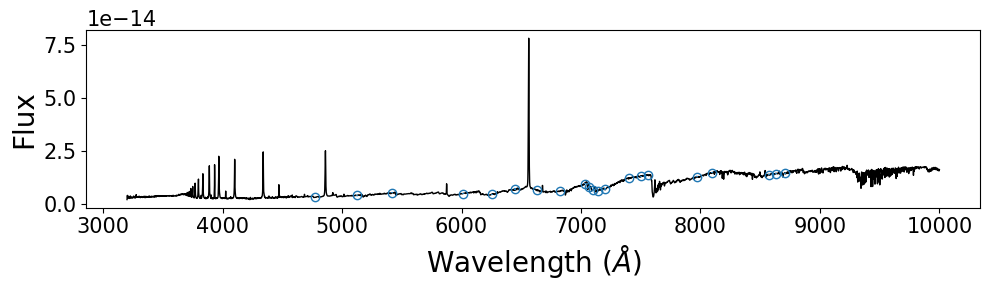

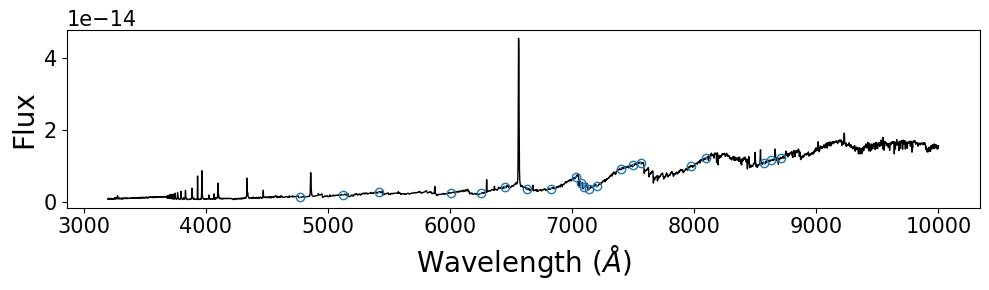

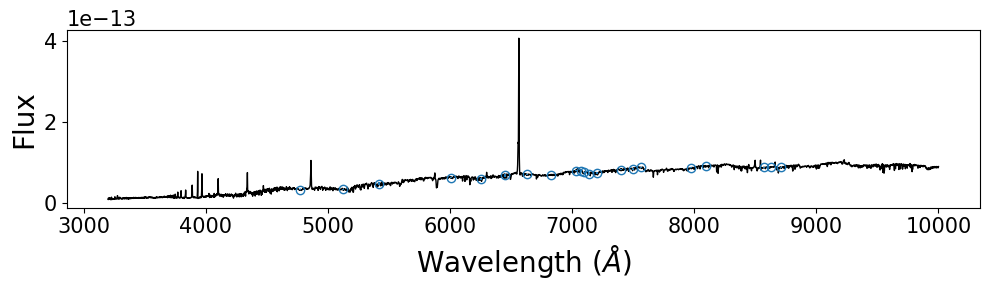

In [12]:
# Same for Lupus X-shooter data
xs_input_obs = np.zeros(shape=(len(xs_spec_array), len(config.y_names)))
xs_input_unc = np.zeros(shape=(len(xs_spec_array), len(config.y_names)))

# Rv data (index=0)
i_Rv = config.y_names.index('R_V')
xs_input_obs[:, i_Rv] = 3.1
xs_input_unc[:, i_Rv] = 0.05 # 5% (arbitrary)

# Flux data : median and standard deviation/median
# Extract median from +/-10 A window for each wavelength
wl = wl_xshooter # wavelengths of obs data
dwl = 10
for i, spec in enumerate(xs_spec_array):
    for wl0, yind in zip(wl_used, i_fluxloc):
        id_min = np.abs(wl -(wl0 - dwl)).argmin()
        id_max = np.abs(wl -(wl0 + dwl)).argmin()

        flux = spec[id_min:id_max+1]
        # Recommend: flux > 0
        roi_pos = flux > 0
        median = np.nanmedian(flux[roi_pos])
        std = np.nanstd(flux[roi_pos])

        xs_input_obs[i, yind] = median
        xs_input_unc[i, yind] = std/median

print("Uncertainty:",xs_input_unc[0])

# Check the median values
for i in range(len(xs_spec_array)):
    fig, ax = plt.subplots(1,1, figsize=[10, 3], tight_layout=1)
    ax.plot(wl_xshooter, xs_spec_array[i], lw=1, color='k',  label="Observed spectrum" )
    ax.errorbar(wl_used, xs_input_obs[i, i_fluxloc], yerr=xs_input_unc[i, i_fluxloc]*xs_input_obs[i, i_fluxloc],
                     ls='', marker='o', color='C0', mfc='none', mec='C0', ecolor='C0', label="Extracted input")
    ax.set(xlabel="Wavelength ($\AA$)", ylabel="Flux")


## Normalize flux

In [13]:
# Combine to one array for all observations to run with the same network
obs_array = np.vstack([muse_input_obs, xs_input_obs])
unc_array = np.vstack([muse_input_unc, xs_input_unc])

# Normalixe flux points
obs_array[:, i_fluxloc] = obs_array[:, i_fluxloc]/np.nansum(obs_array[:, i_fluxloc], axis=1).reshape(-1,1)
print("Sum after normalization:", np.sum(obs_array[0, i_fluxloc]))

Sum after normalization: 1.0


# 5. Posterior sampling

## Setup device: cuda, mps, cpu

In [14]:
device = 'cpu' # cpu, mps, cuda (cuda:0, cuda:1)
if torch.cuda.is_available():
  print(f"CUDA GPU Available")
  # You can simply check !nvidia-smi and choose device.

  # Or if you installed gputil and want to find a GPU with enough memory left
  print( exp.find_gpu_available())
    # Default setup for finding
    # min_free_memory_mib = None  # Minimum available VRAM in MiB.
    # gpu_max_load = 0.5         # Maximum compute load of GPU allowed in automated selection
    # gpu_max_memory = 0.5         # Maximum memory load of GPU allowed in automated selection
    # gpu_wait_s = 600             # Time (s) to wait between tries to find a free GPU if none was found
    # gpu_attempts = 10            # Number of times to retry finding a GPU if none was found
    # if you think only 10% of the current GPU is enough for your workload, you can set
    # gpu_max_load = 0.1, gpu_max_memory = 0.1
  device = exp.find_gpu_available(gpu_max_load = 0.1, gpu_max_memory = 0.1)
  print("GPU found:", device )
elif torch.backends.mps.is_available() * torch.backends.mps.is_built(): # Mac GPU
  print(f"Apple GPU (MPS) Available")
  device = 'mps'
else:
  device = 'cpu'

print(f"Selected device: {device}")

CUDA GPU Available
[1/10] Searching for an available GPU...
Found available physical GPU IDs: [0]
cuda:0
[1/10] Searching for an available GPU...
Found available physical GPU IDs: [0]
GPU found: cuda:0
Selected device: cuda:0


In [15]:
config.device = device
# [Note] If you want to change devcie after you once loaded your network model or once used your network
# you first need to release your network
# config.load_network_model()
if config.network_model is not None:
  print("Your network is loaded")
  print(f"Loaded on: {next(config.network_model.parameters()).device}")

  # # If you want to release the network use followings:
  # config.network_model = None
  # import gc
  # gc.collect()
  # if torch.cuda.is_available(): torch.cuda.empty_cache()
  # elif torch.backends.mps.is_available() * torch.backends.mps.is_built(): torch.mps.empty_cache()
else:
  print("Network is not yet loaded")
  print("When you use posterior sampling, it will automatically load the network.")
  print("If you want to load the network in advance,")
  print("config.load_network_model()")

Network is not yet loaded
When you use posterior sampling, it will automatically load the network.
If you want to load the network in advance,
config.load_network_model()


In [16]:
N_pred = 4096 # Number of posterior samples per observation
group_size = 200 # Numer of observations to handle at once. Depends on your GPU memory
if config.device=='cpu':
  use_group = False
  # torch.set_num_threads(1)
else:
  use_group = True
post_list, llike_list = exp.get_posterior(obs_array, config, N=N_pred, return_llike=True, # return_llike=False (default)
                                          unc=unc_array, use_group=use_group, group=group_size)

print(f"post_list.shape: {post_list.shape}") # N_obs, N_pred, x_dim
print(f"llike_list.shape: {llike_list.shape}") # N_obs, N_pred

post_list.shape: (6, 4096, 9)
llike_list.shape: (6, 4096)


In [17]:
# for mac users to check GPU using (No nvidia-smi like command)
# use mac activity monitor
# or install "asitop"

!nvidia-smi

Tue Apr 21 08:10:27 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   47C    P0             26W /   70W |     341MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

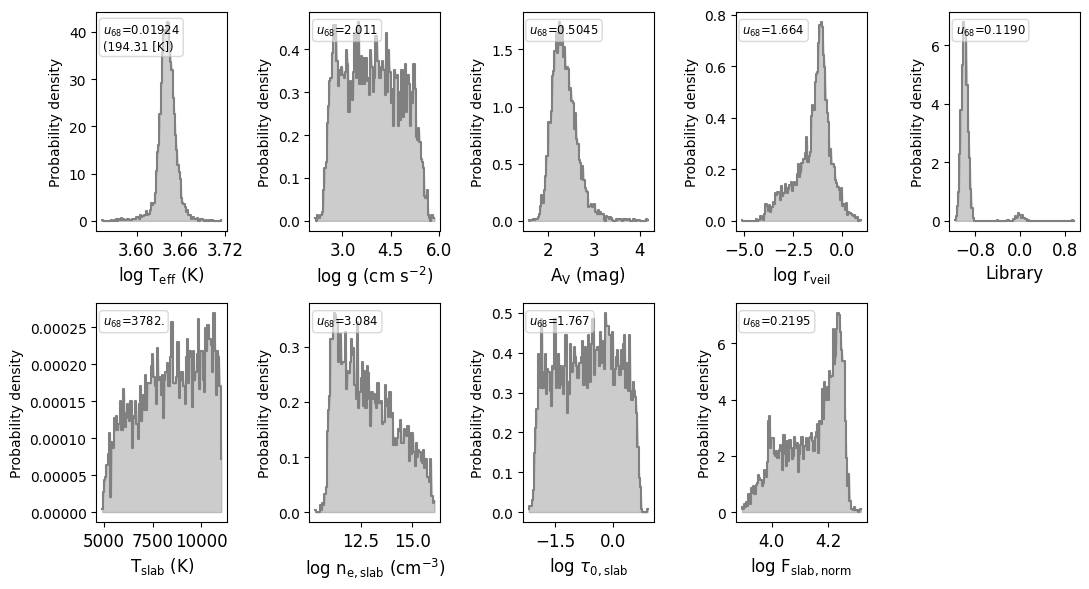

In [18]:
# simple check: 1D posterior distribution
# 9-dimension
target = 1

fig, axis = plt.subplots(2,5, figsize=[11,6], tight_layout=1)
axis=axis.ravel() # make to 1d array
exp.plot_posterior(post_list[target], axis, config, nbin=100, calculate_u68=True) # calculate_u68=True (default)
axis[-1].axis('off')

## Deal with larget dataset > 2000 (run only when GPU is available!!!)

In [ ]:
# expand to large data
obs_expanded = np.broadcast_to(obs_array, (500, *obs_array.shape)).reshape(-1, obs_array.shape[1])
print(f"obs_expanded.shape: {obs_expanded.shape}")
unc_expanded = np.broadcast_to(unc_array, (500, *unc_array.shape)).reshape(-1, unc_array.shape[1])
# 3000 obs


N_pred = 4096 # Number of posterior samples per observation
group_size = 500 # Numer of observations to handle at once. Depends on your GPU memory

t_start = time()
post_list_exp, llike_list_exp = exp.get_posterior(obs_expanded, config, N=N_pred, return_llike=True, # return_llike=False (default)
                                          unc=unc_expanded, use_group=True, group=group_size)

t_end = time()
dt = t_end - t_start
speed = obs_expanded.shape[0]/dt
print(f"Time for {obs_expanded.shape[0]:d} obs: {(dt):.3f}sec")
print(f"Speed with group size {group_size:d}: {speed:.6g} obs/sec")
print(f"post_list.shape: {post_list_exp.shape}") # N_obs, N_pred, x_dim
print(f"llike_list.shape: {llike_list_exp.shape}") # N_obs, N_pred


obs_expanded.shape: (3000, 22)
Time for 3000 obs: 48.050sec
Speed with group size 500: 62.4346 obs/sec
post_list.shape: (3000, 4096, 9)
llike_list.shape: (3000, 4096)


In [ ]:
!nvidia-smi

Tue Apr 21 07:59:59 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   62C    P0             27W /   70W |   12517MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# 6. MAP and Uncertainty  

## SAPSAL-v3
It is highly recommended to keep parameter correlations between 9 parameters. To do so, you may find a best representative posterior sample among N_pred candidates or use 9-D kernel density estimation (KDE) to find the peak of 9D distribution. If you use low-dimensional histogram ($<$9D) or make averages for parameters, you will lose parameter correlations. This is critical for veiling and slab parameters.


## SAPSAL-v2, -v1
Stellar parameters are also degenerate, but they usually show a clear 1-mode posterior distribution in these networks. Using KDE for 1D posterior distribution still has a limit but acceptable for these networks. Always check the original posterior distribution!

## SAPSAL-v3: find_map_zone
- This function uses log-likelihood probability ($P$) of each posteiror samples. If you used return_llike=True for get_posterior, you will retrieve llike values.
> post_list, llike_list = exp.get_posterior(obs_array, config, N=N_pred, return_llike=True, unc=unc_array, use_group=True, group=group_size) # return_llike=False (default)

- It returns the index of MAP sample and boolean array that defines the region for uncertainty calculation
> argmap, roi_unc = exp.find_map_zone(post, llike)



### How it works
1. Define **High probability zone (HPZ)**: $$ P > P_{\text{max}} - \text{threshold} $$
- The first threshold is $2.0$, corresponding to 2-$\sigma$:  $$ P > P_{\text{max}} - 2.0 $$

- If $N_{\text{HPZ}} < 0.01 \times N_{\text{posterior}}$,
it increases the threshold to 2.1, 2.2, 2.3... upto 3-$\sigma$: $ P > P_{\text{max}} - 4.5 $

2. Find **MAP with maximum log-likelihood**:
$$ \mathbf{x}_{\text{MAP}} = \mathop{\arg\max}_{\mathbf{x}_i} P(\mathbf{x}_i) $$

3. Check if MAP is well centered in HPZ
- Calculate a Mahalanobis distance between weighted average point of HPZ and MAP. (weights = $e^{P}$)
- **If MAP is outside of 68% confidence**, **change the MAP points with minimum Mahalanobis distance to the weighted average point**.
- Mahalobis distance: $$ D_M(\mathbf{x}) = \sqrt{(\mathbf{x} - \bar{\mathbf{x}})^T S^{-1} (\mathbf{x} - \bar{\mathbf{x}})} $$

4. Define Uncertainty zone:
- HPZ may include 1-2 extreme outliers.
- Exclude samples in HPZ located outside 95% confidence (use Mahalobis distance of each sample to the MAP point)

331 samples included in Uncertainty zone
map_values: [ 3.51179968e+00  3.74678093e+00  7.98437070e-01 -8.75351090e-01
 -1.00447876e+00  9.41508941e+03  1.15913234e+01 -7.97188071e-02
  4.18143998e+00]


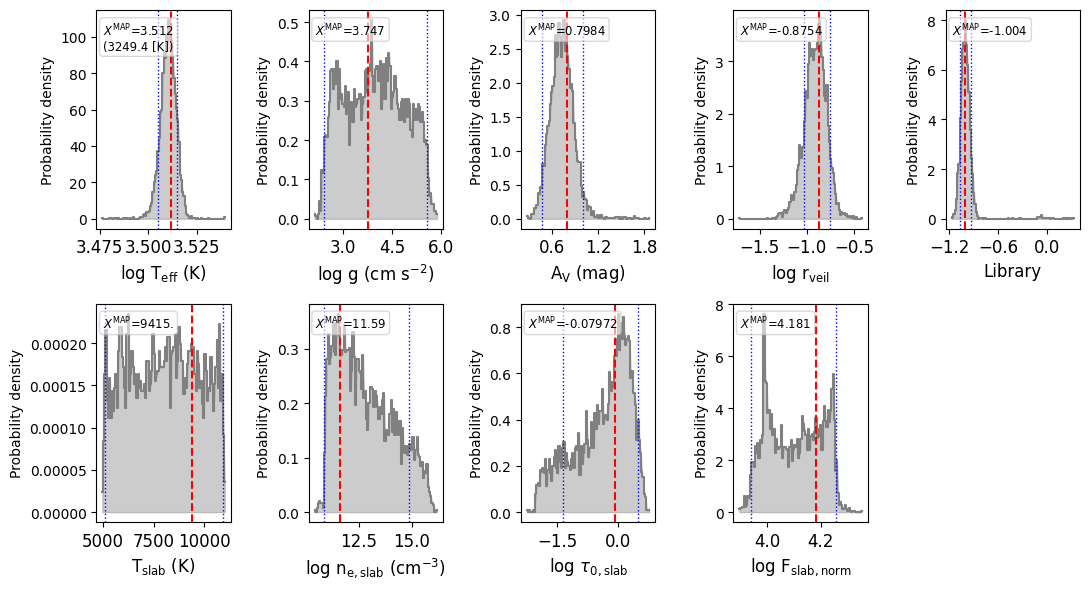

In [19]:
target = 4

post = post_list[target]
llike = llike_list[target]

arg_map, roi_unc = exp.find_map_zone(post, llike, verbose=True,
                                    n_sig_threshold = 2.0,min_uncsample_fraction=0.01,
                                    robust_map=True, confidence_map=0.68,
                                    robust_unc=True, confidence_unc=0.95,)

print(f"{np.sum(roi_unc)} samples included in Uncertainty zone")

map_values = post[arg_map]
upper = np.nanmax(post[roi_unc, :], axis=0)
lower = np.nanmin(post[roi_unc, :], axis=0)
print(f"map_values: {map_values}")


fig, axis = plt.subplots(2,5, figsize=[11,6], tight_layout=1)
axis=axis.ravel()
exp.plot_posterior(post_list[target], axis, config, nbin=100, calculate_u68=False,
                   map_values=map_values, color_map='r')
axis[-1].axis('off')
for i in range(config.x_dim):
  ax = axis[i]
  # ax.axvline(x=map_values[i], color='r', label='MAP')
  ax.axvline(x=upper[i], color='b', ls=':', lw=1)
  ax.axvline(x=lower[i], color='b', ls=':', lw=1)


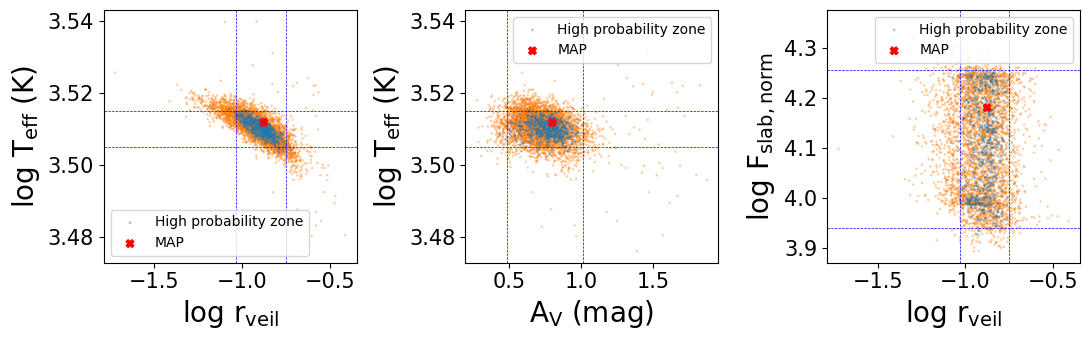

In [20]:
# 2D posteiror distribution examples
fig, axis = plt.subplots(1,3, figsize=[11,3.5], tight_layout=1)
axis = axis.ravel()
for i_case, (param1, param2) in enumerate([('logTeff', 'log_veil_r'),('logTeff', 'A_V'), ('log_Fslab', 'log_veil_r')]):
    ax = axis[i_case]
    roi_high = llike > np.nanmax(llike)-2.0
    arg_max = np.argmax(llike)

    yval = post[:, config.x_names.index(param1)]
    xval = post[:, config.x_names.index(param2)]

    ax.scatter(xval[roi_high], yval[roi_high], marker='.',s=5, ls='', color='C0', alpha=0.3, label="High probability zone")
    ax.scatter(xval[np.invert(roi_high)], yval[np.invert(roi_high)], s=3, marker='.', alpha=0.3, ls='', color='C1', zorder=0)
    ax.scatter( [xval[arg_map]], [yval[arg_map]], marker='X', s=30, ls='', color='r',  label="MAP")
    if arg_map != arg_max:
        ax.scatter( [xval[arg_max]], [yval[arg_max]], marker='P', s=30, ls='', color='g',  label="argmax(P)")

    ax.axvline(upper[config.x_names.index(param2)], ls='--', color='b', lw=0.5)
    ax.axvline(lower[config.x_names.index(param2)], ls='--', color='b', lw=0.5)
    ax.axhline(upper[config.x_names.index(param1)], ls='--', color='b', lw=0.5)
    ax.axhline(lower[config.x_names.index(param1)], ls='--', color='b', lw=0.5)
    ax.legend()
    ax.set(xlabel=exp.get_title(param2), ylabel=exp.get_title(param1))

In [21]:
# Better to save arg_map and roi_unc for secondary parameters
args_map = np.zeros(post_list.shape[0]).astype(int)
roi_unc_list = np.zeros(llike_list.shape).astype(bool)
lerr_list = []; uerr_list = []; map_list = []
for target, (post, llike) in enumerate(zip(post_list, llike_list)):
  arg_map, roi_unc = exp.find_map_zone(post, llike, verbose=True,
                                    n_sig_threshold = 2.0, min_uncsample_fraction=0.01,
                                    robust_map=True, confidence_map=0.68,
                                    robust_unc=True, confidence_unc=0.95,)
  args_map[target] = arg_map
  roi_unc_list[target] = roi_unc

  map_vals = post[arg_map]
  unc_post_area = post[roi_unc]
  maxis = np.nanmax(unc_post_area, axis=0)
  minis = np.nanmin(unc_post_area, axis=0)
  lerr_list.append(map_vals - minis)
  uerr_list.append(maxis - map_vals)
  map_list.append(map_vals)

lerr_list = np.array(lerr_list)
uerr_list = np.array(uerr_list)
map_list = np.array(map_list)

from astropy.table import Table
map_table = Table(map_list, names=config.x_names)
err_table = Table(lerr_list, names=[param+'_errL' for param in config.x_names])
for i, param in enumerate(config.x_names):
  err_table[param+'_errU'] = uerr_list[:,i]


net_code = 'v3_vis'
config_dic[net_code]['args_map'] = args_map
config_dic[net_code]['roi_unc_list'] = roi_unc_list
config_dic[net_code]['post_list'] = post_list
config_dic[net_code]['llike_list'] = llike_list
config_dic[net_code]['map_table'] = map_table
config_dic[net_code]['err_table'] = err_table
map_table

logTeff,logG,A_V,log_veil_r,library,Tslab,log_ne,log_tau0,log_Fslab
float64,float64,float64,float64,float64,float64,float64,float64,float64
3.589642341339531,4.669244022711885,3.149832966408021,-1.2136065688441808,-0.9877421937649374,10189.814176009517,11.243291764558036,-1.7827039541620762,4.249778610401774
3.641766574674523,3.4208723272939547,2.3091705305651797,-1.1902665425928456,-1.0009427958382586,8906.757119694013,11.230878252786065,-1.7809880701470695,4.218161559130882
3.5651453298653633,4.805387765242639,2.6461657958946416,-1.8105286954137956,-0.9821105383826014,10478.59863222074,11.150162921420739,-1.4899534314570388,4.253602563636635
3.52756234689825,3.9233197226222045,0.47862687447465113,-0.7188394494677954,-0.9767805111166223,5173.6536460629895,15.324496512287865,-1.361958115082333,3.990326729545658
3.5117996846574133,3.7467809329051818,0.7984370703680659,-0.8753510898770248,-1.0044787625917344,9415.089412341387,11.591323367205467,-0.07971880705118128,4.181439976788045
3.6222470326960914,3.8589023073399717,1.0505043628894537,-1.4605030291352077,-0.9899452861458508,8954.628308478825,11.137916495171051,-1.8210924168874747,4.21965175737214


# 7. Resimulation

In [22]:
# general setup
import astropy.units as units

wl_grid = 'X-shooter' # option: X-shooter , MUSE
slab_kwargs={"wl_sp": 7500, "Zi":1, "wl_sp_unit":units.AA,
             "include_Hn":True, "Int_lam":True, "lam_unit":units.AA} # DO NOT CHANGE!!!!

# Run for each MAP values
# prepare astropy table with all parameters
param_table = config_dic['v3_vis']['map_table'].copy()

# For v3 networks: Vis-Net, UV-Net
grid_model = 'phoenix_and_frappe'
phoenix_type = 'SpDx'

# Prepare additional data
Rv_values = obs_array[:, config.y_names.index('R_V')] # needed for reddening


t1 = time()
resim_dic = sapsal.resim.run_resimulation(param_table, wl_grid=wl_grid,
                                          grid_model=grid_model, phoenix_type=phoenix_type,
                                          config=config,
                                            return_all=True, # (return_veil=False, return_normalization=False)
                                            clip_logG=True, fixed_logg=4.0, # kwarg for prepare_resim_params
                                            rv_values = Rv_values, use_multiprocessing=False, N_cpu=None,  # kwarg for run_veiling_and_extinction
                                            verbose=True)
t2 = time()
print(f"Finished resimulation for all {len(param_table)} stars")
print(f"key in resim_dic:", resim_dic.keys())
print(f"Time taken for {len(param_table)} models: {(t2-t1):.2f}sec \n")

config_dic['v3_vis']['resim_dic'] = resim_dic

Preparing resimulation parameters (FRAPPE, X-shooter wavelength grid)
	SpT not in param_table, converting SpTind to SpT
	Invalid SpT(SpTind) cases: 0 models
	SpT extrapolated cases: 0 models
	Total 6 models to run.
	0 models fail. Success: 6 models.
Resimulating photosphere...
	Run FRAPPE
===== FRAPPE grid information =====
Used grid: Tpl_G8_M9.5_XSLowRes_rad2.5_deg2_Nmc1000.npz
Grid with 5881 spectral bins, wl: [320.000, 1000.000]nm with dwl=0.0842773 nm, normalized at 750 nm 

SpT in grid (52): ['G8.0' 'G9.0' 'K0.0' 'K0.5' 'K0.5' 'K0.5' 'K1.0' 'K1.0' 'K2.0' 'K2.0'
 'K2.0' 'K3.0' 'K4.0' 'K5.5' 'K6.0' 'K6.0' 'K6.0' 'K6.0' 'K7.0' 'K7.0'
 'K7.5' 'K7.5' 'K7.5' 'K7.5' 'M0.0' 'M0.5' 'M1.0' 'M1.0' 'M2.0' 'M3.0'
 'M3.0' 'M3.0' 'M3.0' 'M3.0' 'M3.5' 'M4.0' 'M4.5' 'M4.5' 'M5.0' 'M5.0'
 'M5.0' 'M5.5' 'M5.5' 'M5.5' 'M5.5' 'M5.5' 'M6.5' 'M7.0' 'M7.5' 'M8.0'
 'M9.0' 'M9.5']

	In all resimulations, 0.0 w/ NaN, 0.0 w/ Neg, 0.0 w/ Zero cases exist!!
Applying veiling and reddening for 6 models
	Run slab

Text(0.5, 1.0, '4')

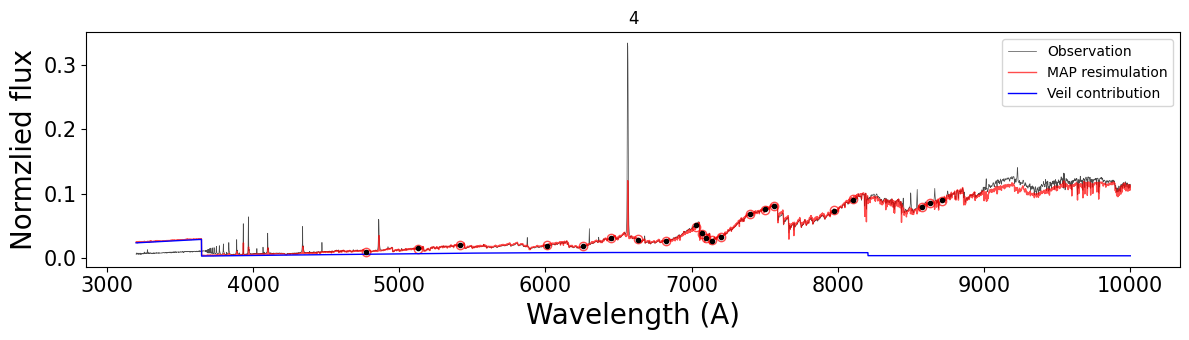

In [23]:
target = 4


wl_resim = sapsal.resim.get_wavelength(wl_grid=wl_grid)
if target < 3:
  wl_obs = wl_muse
  flux = muse_spec_array[target]; obs_norm = np.sum(muse_input_obs[target, i_fluxloc])
else:
  wl_obs = wl_xshooter
  flux = xs_spec_array[target-3]; obs_norm = np.sum(xs_input_obs[target-3, i_fluxloc])

fig, ax = plt.subplots(figsize=[12,3.5], tight_layout=1)
ax.plot(wl_obs, flux/obs_norm, label="Observation", color='k', lw=0.5, alpha=0.7)

# y_yr = np.stack([flux[:50], flux[-50:]])/obs_norm
# yr = [np.nanmin(y_yr)*0.9, np.nanmax(y_yr)*1.1]


yy = obs_array[target, i_fluxloc]
yerr = yy*unc_array[target, i_fluxloc]
ax.errorbar(wl_used, yy, yerr, color='k', marker='o', markersize=3, ls='')


y_resim = resim_dic['spec_resim'][target]; resim_norm=resim_dic['norm_factor'][target]
ax.plot(wl_resim, y_resim/resim_norm, label="MAP resimulation", color='r', alpha=0.7, lw=1)
ax.plot(resim_dic['wl_used'], resim_dic['resim_used'][target]/resim_norm, alpha=0.7, marker='o', ls='', markerfacecolor="None", markeredgecolor='r')
y_veil = resim_dic['reddened_veiling_resim'][target]
ax.plot(wl_resim, y_veil/resim_norm, label="Veil contribution", color='b', alpha=1, lw=1)
ax.legend()
ax.set(ylabel="Normzlied flux", xlabel=r"Wavelength (A)")
# ax.set_ylim(yr)
ax.set_title(f"{target:d}")
# ax.set_ylim([-0.0, 0.1])
# mpld3.display(fig)

# 8. Secondary parameters
Only for v3 network.
$$
\begin{aligned}
\log L_{\text{acc}} &= \log(4\pi d^2) + \log F_{\text{slab,norm}} + \log \left( \frac{r_{\text{veil}}}{1 + r_{\text{veil}}} \right) \\
&\quad + 0.4 A_{7500} + \log f_{7500, \text{obs}}
\end{aligned}
$$

If you want to get proper uncertainty for the secondary parameter, you need to calculate for whole posterior samples (or at least for samples in unceratinty zone)

In [24]:
from astropy import constants as cst
from astropy import units as units
from astropy.io import ascii

In [25]:
# read BC table
bc_table = ascii.read(sapsal_path+"/examples/BC_C24_HH14.txt")
bc_table
bc_table['Teff'] = bc_table['Teff'].astype(float)
bc_table.sort('Teff')
print(bc_table.colnames)

from scipy.interpolate import interp1d
BC_7510_intrp = interp1d(bc_table['Teff'], bc_table['HH14'], kind='linear', fill_value="extrapolate")

['Teff', 'HH14', 'C24']


In [26]:
# Use original flux values (with physical unit) at 7500A or some bins aroud 7500A
distance = np.array([2.35e3, 2.35e3, 2.35e3, 200, 150, 200 ])

distance_unit = cst.pc.to(units.cm).value
Lsun = cst.L_sun.to(units.erg/units.s).value
lum_unit = distance_unit *distance_unit /Lsun

# 7500A is included in v3 network input
f7500_obs = np.hstack([muse_input_obs[:, config.y_names.index('f7500')], xs_input_obs[:, config.y_names.index('f7500')]])
wl = np.array([7500])

Lacc_post_list = np.zeros(llike_list.shape)

map_table = config_dic['v3_vis']['map_table']
err_table = config_dic['v3_vis']['err_table']
map_table['Lacc'] = np.zeros(len(map_table))+np.nan
err_table['Lacc_errL'] = np.zeros(len(map_table))+np.nan
err_table['Lacc_errU'] = np.zeros(len(map_table))+np.nan

for target, post in enumerate(post_list):
  Av_values = post[:, config.x_names.index('A_V')] # posterior samples
  Rv_values = obs_array[target, config.y_names.index('R_V')] # one per obs
  r_values = 10**post[:, config.x_names.index('log_veil_r')] # posterior samples
  Fslab_norm = 10**post[:, config.x_names.index('log_Fslab')] # posterior samples

  f_obs_post = np.tile(f7500_obs[target], len(post)).reshape(-1,1) # repeat the same f7500
  # 1) Deredden spectra
  f_drd_7500 = exp.deredden_spectrum(wl, f_obs_post, Av_values, Rv_values).ravel() # N_pred, 1

  # Fbol_acc
  F_acc_post = r_values / (1+r_values) * f_drd_7500 * Fslab_norm #* units.erg / units.cm / units.cm / units.s # erg/cm2/s

  L_acc_post = ( 4*np.pi* (distance[target])**2 * F_acc_post) * lum_unit
  L_acc_post = np.log10(L_acc_post)
  Lacc_post_list[target] = L_acc_post

  # add map and error info
  arg_map = config_dic['v3_vis']['args_map'][target]
  roi_unc = config_dic['v3_vis']['roi_unc_list'][target]
  map_table['Lacc'][target] = L_acc_post[arg_map]
  err_table['Lacc_errL'][target] = L_acc_post[arg_map] - np.nanmin(L_acc_post[roi_unc])
  err_table['Lacc_errU'][target] = np.nanmax(L_acc_post[roi_unc]) - L_acc_post[arg_map]

  # If you have BC at 7500A you can use below

  ## 2) Deveil for L*
  ## if you are only using f7500:
  ## photosphere(7500) = deredden(7500) * (1/(1+r))
  # f_phot_7500 = f_drd_7500 / (1+r_values)

  ## To get Fbol_post, you need your own bolometric correction.
  ## Fbol_post = 10**bc7500 * f750 # erg/s/cm2
  # Lbol_post = np.log10( 4*np.pi* (distance[target])**2 * Fbol_post) * lum_unit

config_dic['v3_vis']['Lacc_post_list'] = Lacc_post_list


In [27]:
# If you use BC for other wavelength. you need to deredden and deveil spectra including 7500A and that wavelength
# It may takes time: making slab for all posteiror for all targets
# This example uses BC at 7510.

# Use original flux values (with physical unit) at 7500A or some bins aroud 7500A
distance = np.array([2.35e3, 2.35e3, 2.35e3, 200, 150, 200 ])

distance_unit = cst.pc.to(units.cm).value
Lsun = cst.L_sun.to(units.erg/units.s).value
lum_unit = distance_unit *distance_unit /Lsun


Lbol_post_list = np.zeros(llike_list.shape)

map_table = config_dic['v3_vis']['map_table']
err_table = config_dic['v3_vis']['err_table']
map_table['Lbol'] = np.zeros(len(map_table))+np.nan
err_table['Lbol_errL'] = np.zeros(len(map_table))+np.nan
err_table['Lbol_errU'] = np.zeros(len(map_table))+np.nan

for target, post in enumerate(post_list):
  if target < 3:
    wl_obs = wl_muse
    spec = muse_spec_array[target]
  else:
    wl_obs = wl_xshooter
    spec = xs_spec_array[target-3]

  # Setup a minimum wavelength bins needed. In this case wl should include 7500~7510
  id750 = np.abs(wl_obs - 7500.).argmin()
  id751 = np.abs(wl_obs - 7510.).argmin()
  ind_750 = np.arange(id750-7, id751+7, 1)

  flux = spec[ind_750]
  wl = wl_obs[ind_750]

  Av_values = post[:, config.x_names.index('A_V')] # posterior samples
  Rv_values = obs_array[target, config.y_names.index('R_V')] # one per obs
  r_values = 10**post[:, config.x_names.index('log_veil_r')] # posterior samples
  Fslab_norm = 10**post[:, config.x_names.index('log_Fslab')] # posterior samples

  f_obs_post = np.tile(flux, (len(post),1)) # repeat the same spectra

  # 1) Deredden spectra
  f_drd = exp.deredden_spectrum(wl, f_obs_post, Av_values, Rv_values) # 2D: N_pred, len(flux)

  # 2) Deveil for L*
  # for v3 network: need to produce slab spectra
  Tslab_values = post[:, config.x_names.index('Tslab')] # posterior samples
  logne_values = post[:, config.x_names.index('log_ne')] # posterior samples
  logtau0_values = post[:, config.x_names.index('log_tau0')] # posterior samples
  slab_variables = [Tslab_values, logne_values, logtau0_values]

  # Run slab to get fslab(7500)
  slab_kwargs={"wl_sp": 7500, "Zi":1, "wl_sp_unit":units.AA, "include_Hn":True, "Int_lam":True, "lam_unit":units.AA}
  fslab = np.array( [sapsal.HSlabModel.get_total_intensity(wl, t, 10**ne, 10**tau, **slab_kwargs) for t, ne, tau in zip(Tslab_values, logne_values, logtau0_values)] )
  # slab spectra should be normalized at its f(7500)
  f750_array = exp.get_flux_at(wl, fslab, target_wl=slab_kwargs["wl_sp"])
  fslab_norm = fslab / f750_array.reshape(-1,1)

  # Deveil
  f_phot, veiling = exp.remove_veil(wl, f_drd, r_values, fslab_norm = fslab_norm, return_veil=True)

  # We will use BC from HH14 (BC at 7510): BC = F7510/Fbol
  # make BC for each posterior using Teff
  t_values = 10**post[:, config.x_names.index('logTeff')]
  bc7510 = BC_7510_intrp(t_values)
  f_phot_7510 = exp.get_flux_at(wl, f_phot, target_wl=7510, n_bins=3) # use +-3 bins
  Fbol_post = f_phot_7510 / bc7510

  Lbol_post = np.log10( 4*np.pi* (distance[target])**2 * Fbol_post * lum_unit)
  Lbol_post_list[target] = Lbol_post

  # add map and error info
  arg_map = config_dic['v3_vis']['args_map'][target]
  roi_unc = config_dic['v3_vis']['roi_unc_list'][target]
  map_table['Lbol'][target] = Lbol_post[arg_map]
  err_table['Lbol_errL'][target] = Lbol_post[arg_map] - np.nanmin(Lbol_post[roi_unc])
  err_table['Lbol_errU'][target] = np.nanmax(Lbol_post[roi_unc]) - Lbol_post[arg_map]

config_dic['v3_vis']['Lbol_post_list'] = Lbol_post_list


In [28]:
map_table

logTeff,logG,A_V,log_veil_r,library,Tslab,log_ne,log_tau0,log_Fslab,Lacc,Lbol
float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
3.589642341339531,4.669244022711885,3.149832966408021,-1.2136065688441808,-0.9877421937649374,10189.814176009517,11.243291764558036,-1.7827039541620762,4.249778610401774,-1.1468731581830212,-0.13010537838602135
3.641766574674523,3.4208723272939547,2.3091705305651797,-1.1902665425928456,-1.0009427958382586,8906.757119694013,11.230878252786065,-1.7809880701470695,4.218161559130882,-1.2226906530015207,-0.20952728990367203
3.5651453298653633,4.805387765242639,2.6461657958946416,-1.8105286954137956,-0.9821105383826014,10478.59863222074,11.150162921420739,-1.4899534314570388,4.253602563636635,-2.1179619523944413,-0.49282288867343654
3.52756234689825,3.9233197226222045,0.47862687447465113,-0.7188394494677954,-0.9767805111166223,5173.6536460629895,15.324496512287865,-1.361958115082333,3.990326729545658,-1.4573690004631294,-0.6214271173942914
3.5117996846574133,3.7467809329051818,0.7984370703680659,-0.8753510898770248,-1.0044787625917344,9415.089412341387,11.591323367205467,-0.07971880705118128,4.181439976788045,-1.6671246842220788,-0.8321295474421773
3.6222470326960914,3.8589023073399717,1.0505043628894537,-1.4605030291352077,-0.9899452861458508,8954.628308478825,11.137916495171051,-1.8210924168874747,4.21965175737214,-0.9457103595452487,0.3499882451029627


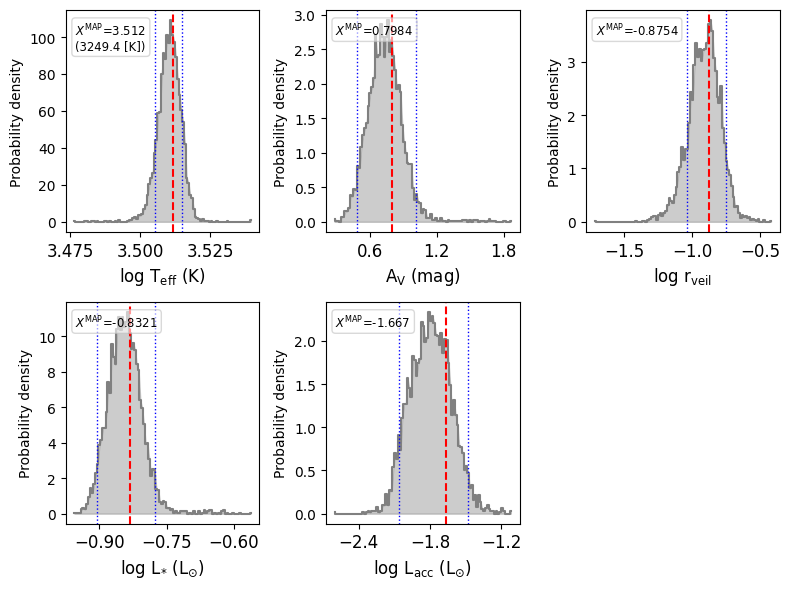

In [29]:
target = 4

plot_params = ['logTeff', 'A_V', 'log_veil_r', 'Lbol', 'Lacc']

ptable = Table(post_list[target], names=config.x_names)
ptable['Lacc'] = config_dic['v3_vis']['Lacc_post_list'][target]
ptable['Lbol'] = config_dic['v3_vis']['Lbol_post_list'][target]

fig, axis = plt.subplots(2,3, figsize=[8,6], tight_layout=1)
axis=axis.ravel() # make to 1d array
exp.plot_posterior(np.column_stack([ptable[col].data for col in plot_params]), axis, config, x_names=plot_params, nbin=100, calculate_u68=False,
                   map_values=[map_table[param][target] for param in plot_params], color_map='r')
axis[-1].axis('off')
for i, param in enumerate(plot_params):
  ax = axis[i]
  up = err_table[param+'_errU'][target] + map_table[param][target]
  lo = map_table[param][target] - err_table[param+'_errL'][target]
  ax.axvline(x=up, color='b', ls=':', lw=1)
  ax.axvline(x=lo, color='b', ls=':', lw=1)


# Practice

## Anlayze three x-shooter examples (xs_spec_array) using UV-Net
- network code: 'v3_uv'

1. Network loading
2. Data-preprocessing for UV-Net (UV-Net has different input format)
3. Posterior sampling
4. MAP, uncerainties
5. Resimulation
6. Derive Lbol and Lacc




In [54]:
# Load multiple networks and keep config
# config_dic = {}
net_codes = ['v3_uv'] #, 'v3_uv']
for net_code in net_codes:
  config_dic[net_code]={}
  config_dic[net_code]['config'] = sapsal.io.load_pretrained_network(net_code, verbose=True)
  config.print_short_setting()
  print()

Requested network: UV-Net (code: v3_uv, Official Name: SAPSAL-v3-UV)
Network config loaded successfully.
==================== cINN NETWORK SETTING =================
cINN_config file: config_v3_UV.py
# of parameters: 9
# of observables: 54
device: cuda:0
Network in Noise-Net mode



In [55]:
# Pre-processing Vis-Net
net_code = 'v3_uv'
config = config_dic[net_code]['config']
print(config.y_names)

# v3 networks only
wl_used = exp.get_wl_used(config.y_names)
print(wl_used)
i_fluxloc = exp.get_flux_loc(config.y_names)
print("index of y_names relevant to flux:", i_fluxloc)

['R_V', 'f3400', 'f3550', 'f3605', 'f4005', 'f4145', 'f4650', 'f4750', 'f5125', 'f5415', 'f6255', 'f6447.5', 'f6630', 'f6825', 'f7030', 'f7070', 'f7100', 'f7140', 'f7200', 'f7400', 'f7500', 'f7560', 'f7975', 'f8100', 'f8575', 'f8630', 'f8710']
[3400.  3550.  3605.  4005.  4145.  4650.  4750.  5125.  5415.  6255.
 6447.5 6630.  6825.  7030.  7070.  7100.  7140.  7200.  7400.  7500.
 7560.  7975.  8100.  8575.  8630.  8710. ]
index of y_names relevant to flux: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26]


Uncertainty: [0.05       0.02462631 0.01428924 0.02126909 0.03405021 0.04375204
 0.02753548 0.03022878 0.02338341 0.03587029 0.03010532 0.04169225
 0.0279321  0.02619236 0.03622072 0.06334134 0.0502986  0.03404734
 0.03441997 0.01238551 0.01715326 0.01079184 0.008163   0.01103666
 0.00917617 0.00697134 0.00973528]


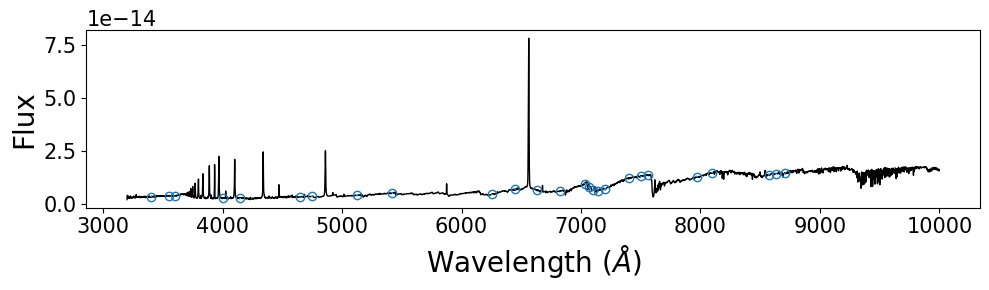

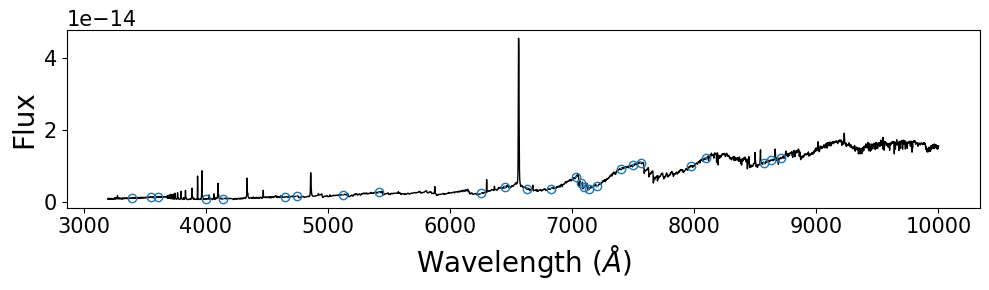

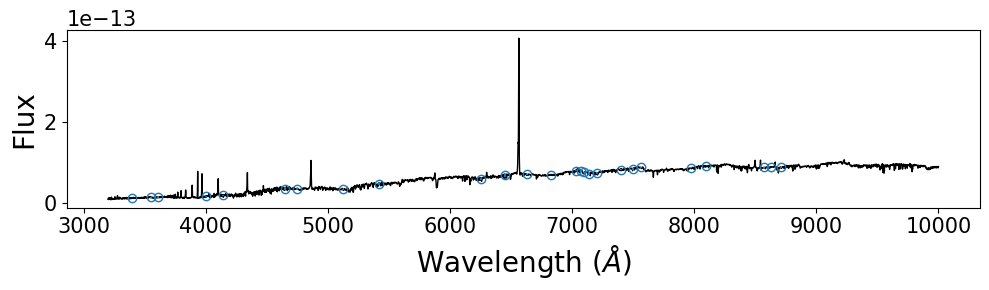

In [56]:
# Same for Lupus X-shooter data
xs_input_obs = np.zeros(shape=(len(xs_spec_array), len(config.y_names)))
xs_input_unc = np.zeros(shape=(len(xs_spec_array), len(config.y_names)))

# Rv data (index=0)
i_Rv = config.y_names.index('R_V')
xs_input_obs[:, i_Rv] = 3.1
xs_input_unc[:, i_Rv] = 0.05 # 5%

# Flux data : median and standard deviation/median
# Extract median from +/-10 A window for each wavelength
wl = wl_xshooter # wavelengths of obs data
dwl = 10
for i, spec in enumerate(xs_spec_array):
    for wl0, yind in zip(wl_used, i_fluxloc):
        id_min = np.abs(wl -(wl0 - dwl)).argmin()
        id_max = np.abs(wl -(wl0 + dwl)).argmin()

        flux = spec[id_min:id_max+1]
        # Recommend: flux > 0
        roi_pos = flux > 0
        median = np.nanmedian(flux[roi_pos])
        std = np.nanstd(flux[roi_pos])

        xs_input_obs[i, yind] = median
        xs_input_unc[i, yind] = std/median

print("Uncertainty:",xs_input_unc[0])

# Check the median values
for i in range(len(xs_spec_array)):
    fig, ax = plt.subplots(1,1, figsize=[10, 3], tight_layout=1)
    ax.plot(wl_xshooter, xs_spec_array[i], lw=1, color='k',  label="Observed spectrum" )
    ax.errorbar(wl_used, xs_input_obs[i, i_fluxloc], yerr=xs_input_unc[i, i_fluxloc]*xs_input_obs[i, i_fluxloc],
                     ls='', marker='o', color='C0', mfc='none', mec='C0', ecolor='C0', label="Extracted input")
    ax.set(xlabel="Wavelength ($\AA$)", ylabel="Flux")


In [57]:
# Combine to one array for all observations to run with the same network
obs_array = xs_input_obs.copy()
unc_array = xs_input_unc.copy()

# Normalixe flux points
obs_array[:, i_fluxloc] = obs_array[:, i_fluxloc]/np.nansum(obs_array[:, i_fluxloc], axis=1).reshape(-1,1)
print("Sum after normalization:", np.sum(obs_array[0, i_fluxloc]))

Sum after normalization: 0.9999999999999999


In [58]:
config.device = device
N_pred = 4096 # Number of posterior samples per observation
group_size = 200 # Numer of observations to handle at once. Depends on your GPU memory
if config.device=='cpu':
  use_group = False
  # torch.set_num_threads(1)
else:
  use_group = True
post_list, llike_list = exp.get_posterior(obs_array, config, N=N_pred, return_llike=True, # return_llike=False (default)
                                          unc=unc_array, use_group=use_group, group=group_size)

print(f"post_list.shape: {post_list.shape}") # N_obs, N_pred, x_dim
print(f"llike_list.shape: {llike_list.shape}") # N_obs, N_pred

post_list.shape: (3, 4096, 9)
llike_list.shape: (3, 4096)


In [59]:
# Better to save arg_map and roi_unc for secondary parameters
args_map = np.zeros(post_list.shape[0]).astype(int)
roi_unc_list = np.zeros(llike_list.shape).astype(bool)
lerr_list = []; uerr_list = []; map_list = []
for target, (post, llike) in enumerate(zip(post_list, llike_list)):
  arg_map, roi_unc = exp.find_map_zone(post, llike, verbose=True,
                                    n_sig_threshold = 2.0, min_uncsample_fraction=0.01,
                                    robust_map=True, confidence_map=0.68,
                                    robust_unc=True, confidence_unc=0.95,)
  args_map[target] = arg_map
  roi_unc_list[target] = roi_unc

  map_vals = post[arg_map]
  unc_post_area = post[roi_unc]
  maxis = np.nanmax(unc_post_area, axis=0)
  minis = np.nanmin(unc_post_area, axis=0)
  lerr_list.append(map_vals - minis)
  uerr_list.append(maxis - map_vals)
  map_list.append(map_vals)

lerr_list = np.array(lerr_list)
uerr_list = np.array(uerr_list)
map_list = np.array(map_list)

from astropy.table import Table
map_table = Table(map_list, names=config.x_names)
err_table = Table(lerr_list, names=[param+'_errL' for param in config.x_names])
for i, param in enumerate(config.x_names):
  err_table[param+'_errU'] = uerr_list[:,i]


net_code = 'v3_uv'
config_dic[net_code]['args_map'] = args_map
config_dic[net_code]['roi_unc_list'] = roi_unc_list
config_dic[net_code]['post_list'] = post_list
config_dic[net_code]['llike_list'] = llike_list
config_dic[net_code]['map_table'] = map_table
config_dic[net_code]['err_table'] = err_table
map_table

logTeff,logG,A_V,log_veil_r,library,Tslab,log_ne,log_tau0,log_Fslab
float64,float64,float64,float64,float64,float64,float64,float64,float64
3.5316370685557974,3.990743958030285,0.6497180900298987,-0.8100526576178976,-0.9786516423330484,8656.97423153204,15.695847522691643,-1.094570709504416,4.104891899036565
3.5140845883681426,4.18316861055033,0.6063477550222642,-1.104825100541126,-0.9784818701197884,7111.523321122231,13.67033445224908,-0.421281634512497,4.046410664124079
3.610193592967643,3.160100779974014,1.3509861954832294,-0.2868022695660293,-1.0022403074480775,5895.07369137589,12.636644132836523,-1.3085656432777064,3.95249920924218


In [60]:
# general setup
import astropy.units as units

wl_grid = 'X-shooter' # option: X-shooter , MUSE
slab_kwargs={"wl_sp": 7500, "Zi":1, "wl_sp_unit":units.AA,
             "include_Hn":True, "Int_lam":True, "lam_unit":units.AA} # DO NOT CHANGE!!!!

# Run for each MAP values
# prepare astropy table with all parameters
param_table = config_dic['v3_uv']['map_table'].copy()

# For v3 networks: Vis-Net, UV-Net
grid_model = 'phoenix_and_frappe'
phoenix_type = 'SpDx'

# Prepare additional data
Rv_values = obs_array[:, config.y_names.index('R_V')] # needed for reddening


t1 = time()
resim_dic = sapsal.resim.run_resimulation(param_table, wl_grid=wl_grid,
                                          grid_model=grid_model, phoenix_type=phoenix_type,
                                          config=config,
                                            return_all=True, # (return_veil=False, return_normalization=False)
                                            clip_logG=True, fixed_logg=4.0, # kwarg for prepare_resim_params
                                            rv_values = Rv_values, use_multiprocessing=False, N_cpu=None,  # kwarg for run_veiling_and_extinction
                                            verbose=True)
t2 = time()
print(f"Finished resimulation for all {len(param_table)} stars")
print(f"key in resim_dic:", resim_dic.keys())
print(f"Time taken for {len(param_table)} models: {(t2-t1):.2f}sec \n")

config_dic['v3_uv']['resim_dic'] = resim_dic

Preparing resimulation parameters (FRAPPE, X-shooter wavelength grid)
	SpT not in param_table, converting SpTind to SpT
	Invalid SpT(SpTind) cases: 0 models
	SpT extrapolated cases: 0 models
	Total 3 models to run.
	0 models fail. Success: 3 models.
Resimulating photosphere...
	Run FRAPPE
===== FRAPPE grid information =====
Used grid: Tpl_G8_M9.5_XSLowRes_rad2.5_deg2_Nmc1000.npz
Grid with 5881 spectral bins, wl: [320.000, 1000.000]nm with dwl=0.0842773 nm, normalized at 750 nm 

SpT in grid (52): ['G8.0' 'G9.0' 'K0.0' 'K0.5' 'K0.5' 'K0.5' 'K1.0' 'K1.0' 'K2.0' 'K2.0'
 'K2.0' 'K3.0' 'K4.0' 'K5.5' 'K6.0' 'K6.0' 'K6.0' 'K6.0' 'K7.0' 'K7.0'
 'K7.5' 'K7.5' 'K7.5' 'K7.5' 'M0.0' 'M0.5' 'M1.0' 'M1.0' 'M2.0' 'M3.0'
 'M3.0' 'M3.0' 'M3.0' 'M3.0' 'M3.5' 'M4.0' 'M4.5' 'M4.5' 'M5.0' 'M5.0'
 'M5.0' 'M5.5' 'M5.5' 'M5.5' 'M5.5' 'M5.5' 'M6.5' 'M7.0' 'M7.5' 'M8.0'
 'M9.0' 'M9.5']

	In all resimulations, 0.0 w/ NaN, 0.0 w/ Neg, 0.0 w/ Zero cases exist!!
Applying veiling and reddening for 3 models
	Run slab

Text(0.5, 1.0, '0')

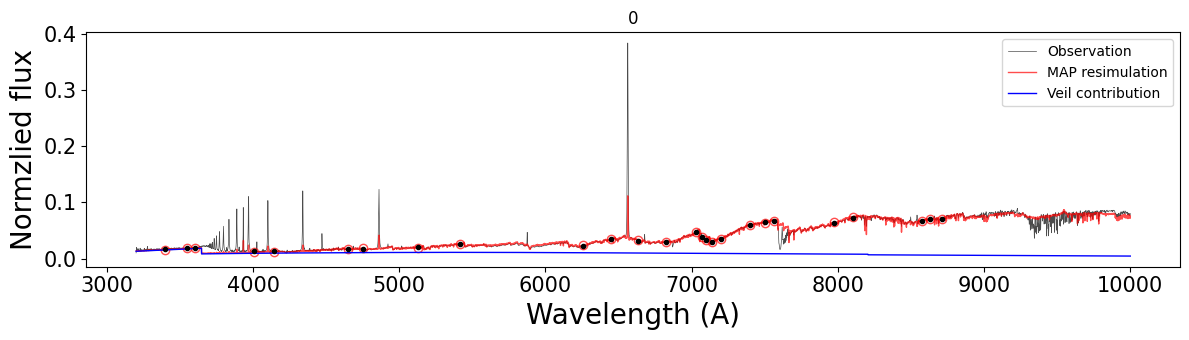

In [66]:
target = 0

wl_resim = sapsal.resim.get_wavelength(wl_grid=wl_grid)

wl_obs = wl_xshooter
flux = xs_spec_array[target]; obs_norm = np.sum(xs_input_obs[target, i_fluxloc])

fig, ax = plt.subplots(figsize=[12,3.5], tight_layout=1)
ax.plot(wl_obs, flux/obs_norm, label="Observation", color='k', lw=0.5, alpha=0.7)

# y_yr = np.stack([flux[:50], flux[-50:]])/obs_norm
# yr = [np.nanmin(y_yr)*0.9, np.nanmax(y_yr)*1.1]


yy = obs_array[target, i_fluxloc]
yerr = yy*unc_array[target, i_fluxloc]
ax.errorbar(wl_used, yy, yerr, color='k', marker='o', markersize=3, ls='')


y_resim = resim_dic['spec_resim'][target]; resim_norm=resim_dic['norm_factor'][target]
ax.plot(wl_resim, y_resim/resim_norm, label="MAP resimulation", color='r', alpha=0.7, lw=1)
ax.plot(resim_dic['wl_used'], resim_dic['resim_used'][target]/resim_norm, alpha=0.7, marker='o', ls='', markerfacecolor="None", markeredgecolor='r')
y_veil = resim_dic['reddened_veiling_resim'][target]
ax.plot(wl_resim, y_veil/resim_norm, label="Veil contribution", color='b', alpha=1, lw=1)
ax.legend()
ax.set(ylabel="Normzlied flux", xlabel=r"Wavelength (A)")
# ax.set_ylim(yr)
ax.set_title(f"{target:d}")
# ax.set_ylim([-0.0, 0.1])
# mpld3.display(fig)

In [62]:
post_list.shape

(3, 4096, 9)

In [68]:
# Use original flux values (with physical unit) at 7500A or some bins aroud 7500A
distance = np.array([200, 150, 200 ])

distance_unit = cst.pc.to(units.cm).value
Lsun = cst.L_sun.to(units.erg/units.s).value
lum_unit = distance_unit *distance_unit /Lsun

# 7500A is included in v3 network input
f7500_obs = xs_input_obs[:, config.y_names.index('f7500')]
wl = np.array([7500])

Lacc_post_list = np.zeros(llike_list.shape)

map_table = config_dic['v3_uv']['map_table']
err_table = config_dic['v3_uv']['err_table']
map_table['Lacc'] = np.zeros(len(map_table))+np.nan
err_table['Lacc_errL'] = np.zeros(len(map_table))+np.nan
err_table['Lacc_errU'] = np.zeros(len(map_table))+np.nan

for target, post in enumerate(post_list):
  Av_values = post[:, config.x_names.index('A_V')] # posterior samples
  Rv_values = obs_array[target, config.y_names.index('R_V')] # one per obs
  r_values = 10**post[:, config.x_names.index('log_veil_r')] # posterior samples
  Fslab_norm = 10**post[:, config.x_names.index('log_Fslab')] # posterior samples

  f_obs_post = np.tile(f7500_obs[target], len(post)).reshape(-1,1) # repeat the same f7500
  # 1) Deredden spectra
  f_drd_7500 = exp.deredden_spectrum(wl, f_obs_post, Av_values, Rv_values).ravel() # N_pred, 1

  # Fbol_acc
  F_acc_post = r_values / (1+r_values) * f_drd_7500 * Fslab_norm #* units.erg / units.cm / units.cm / units.s # erg/cm2/s

  L_acc_post = ( 4*np.pi* (distance[target])**2 * F_acc_post) * lum_unit
  L_acc_post = np.log10(L_acc_post)
  Lacc_post_list[target] = L_acc_post

  # add map and error info
  arg_map = config_dic['v3_uv']['args_map'][target]
  roi_unc = config_dic['v3_uv']['roi_unc_list'][target]
  map_table['Lacc'][target] = L_acc_post[arg_map]
  err_table['Lacc_errL'][target] = L_acc_post[arg_map] - np.nanmin(L_acc_post[roi_unc])
  err_table['Lacc_errU'][target] = np.nanmax(L_acc_post[roi_unc]) - L_acc_post[arg_map]

  # If you have BC at 7500A you can use below

  ## 2) Deveil for L*
  ## if you are only using f7500:
  ## photosphere(7500) = deredden(7500) * (1/(1+r))
  # f_phot_7500 = f_drd_7500 / (1+r_values)

  ## To get Fbol_post, you need your own bolometric correction.
  ## Fbol_post = 10**bc7500 * f750 # erg/s/cm2
  # Lbol_post = np.log10( 4*np.pi* (distance[target])**2 * Fbol_post) * lum_unit

config_dic['v3_uv']['Lacc_post_list'] = Lacc_post_list


In [69]:
# If you use BC for other wavelength. you need to deredden and deveil spectra including 7500A and that wavelength
# It may takes time: making slab for all posteiror for all targets
# This example uses BC at 7510.

# Use original flux values (with physical unit) at 7500A or some bins aroud 7500A
distance = np.array([200, 150, 200 ])

distance_unit = cst.pc.to(units.cm).value
Lsun = cst.L_sun.to(units.erg/units.s).value
lum_unit = distance_unit *distance_unit /Lsun


Lbol_post_list = np.zeros(llike_list.shape)

map_table = config_dic['v3_uv']['map_table']
err_table = config_dic['v3_uv']['err_table']
map_table['Lbol'] = np.zeros(len(map_table))+np.nan
err_table['Lbol_errL'] = np.zeros(len(map_table))+np.nan
err_table['Lbol_errU'] = np.zeros(len(map_table))+np.nan

for target, post in enumerate(post_list):

  wl_obs = wl_xshooter
  spec = xs_spec_array[target]

  # Setup a minimum wavelength bins needed. In this case wl should include 7500~7510
  id750 = np.abs(wl_obs - 7500.).argmin()
  id751 = np.abs(wl_obs - 7510.).argmin()
  ind_750 = np.arange(id750-7, id751+7, 1)

  flux = spec[ind_750]
  wl = wl_obs[ind_750]

  Av_values = post[:, config.x_names.index('A_V')] # posterior samples
  Rv_values = obs_array[target, config.y_names.index('R_V')] # one per obs
  r_values = 10**post[:, config.x_names.index('log_veil_r')] # posterior samples
  Fslab_norm = 10**post[:, config.x_names.index('log_Fslab')] # posterior samples

  f_obs_post = np.tile(flux, (len(post),1)) # repeat the same spectra

  # 1) Deredden spectra
  f_drd = exp.deredden_spectrum(wl, f_obs_post, Av_values, Rv_values) # 2D: N_pred, len(flux)

  # 2) Deveil for L*
  # for v3 network: need to produce slab spectra
  Tslab_values = post[:, config.x_names.index('Tslab')] # posterior samples
  logne_values = post[:, config.x_names.index('log_ne')] # posterior samples
  logtau0_values = post[:, config.x_names.index('log_tau0')] # posterior samples
  slab_variables = [Tslab_values, logne_values, logtau0_values]

  # Run slab to get fslab(7500)
  slab_kwargs={"wl_sp": 7500, "Zi":1, "wl_sp_unit":units.AA, "include_Hn":True, "Int_lam":True, "lam_unit":units.AA}
  fslab = np.array( [sapsal.HSlabModel.get_total_intensity(wl, t, 10**ne, 10**tau, **slab_kwargs) for t, ne, tau in zip(Tslab_values, logne_values, logtau0_values)] )
  # slab spectra should be normalized at its f(7500)
  f750_array = exp.get_flux_at(wl, fslab, target_wl=slab_kwargs["wl_sp"])
  fslab_norm = fslab / f750_array.reshape(-1,1)

  # Deveil
  f_phot, veiling = exp.remove_veil(wl, f_drd, r_values, fslab_norm = fslab_norm, return_veil=True)

  # We will use BC from HH14 (BC at 7510): BC = F7510/Fbol
  # make BC for each posterior using Teff
  t_values = 10**post[:, config.x_names.index('logTeff')]
  bc7510 = BC_7510_intrp(t_values)
  f_phot_7510 = exp.get_flux_at(wl, f_phot, target_wl=7510, n_bins=3) # use +-3 bins
  Fbol_post = f_phot_7510 / bc7510

  Lbol_post = np.log10( 4*np.pi* (distance[target])**2 * Fbol_post * lum_unit)
  Lbol_post_list[target] = Lbol_post

  # add map and error info
  arg_map = config_dic['v3_uv']['args_map'][target]
  roi_unc = config_dic['v3_uv']['roi_unc_list'][target]
  map_table['Lbol'][target] = Lbol_post[arg_map]
  err_table['Lbol_errL'][target] = Lbol_post[arg_map] - np.nanmin(Lbol_post[roi_unc])
  err_table['Lbol_errU'][target] = np.nanmax(Lbol_post[roi_unc]) - Lbol_post[arg_map]

config_dic['v3_uv']['Lbol_post_list'] = Lbol_post_list


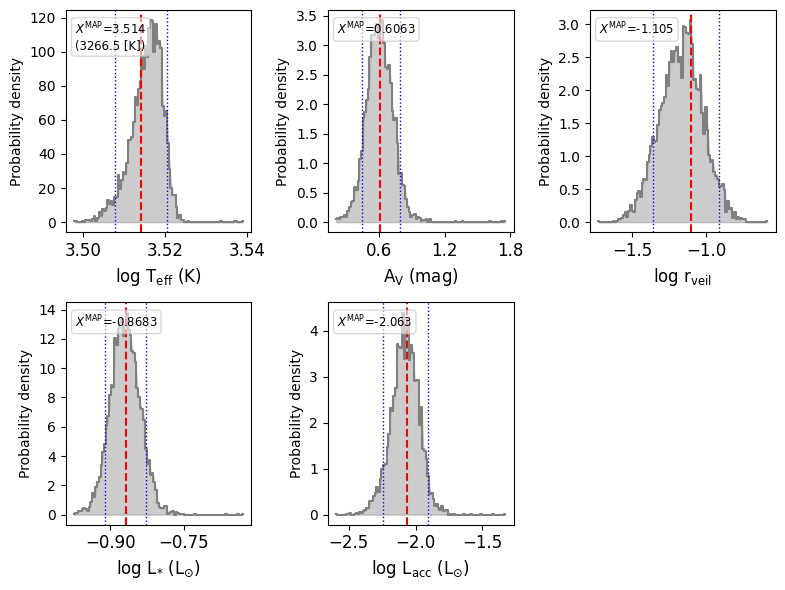

In [70]:
target = 1

plot_params = ['logTeff', 'A_V', 'log_veil_r', 'Lbol', 'Lacc']

post_list = config_dic['v3_uv']['post_list']
ptable = Table(post_list[target], names=config.x_names)
ptable['Lacc'] = config_dic['v3_uv']['Lacc_post_list'][target]
ptable['Lbol'] = config_dic['v3_uv']['Lbol_post_list'][target]

fig, axis = plt.subplots(2,3, figsize=[8,6], tight_layout=1)
axis=axis.ravel() # make to 1d array
exp.plot_posterior(np.column_stack([ptable[col].data for col in plot_params]), axis, config, x_names=plot_params, nbin=100, calculate_u68=False,
                   map_values=[map_table[param][target] for param in plot_params], color_map='r')
axis[-1].axis('off')
for i, param in enumerate(plot_params):
  ax = axis[i]
  up = err_table[param+'_errU'][target] + map_table[param][target]
  lo = map_table[param][target] - err_table[param+'_errL'][target]
  ax.axvline(x=up, color='b', ls=':', lw=1)
  ax.axvline(x=lo, color='b', ls=':', lw=1)


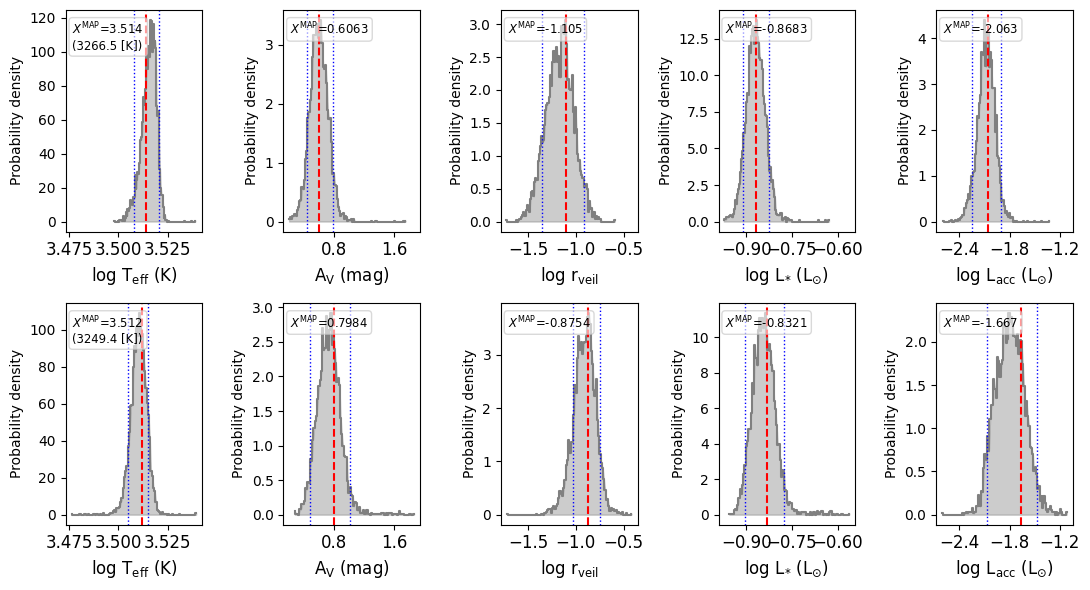

In [72]:
target = 1

plot_params = ['logTeff', 'A_V', 'log_veil_r', 'Lbol', 'Lacc']

post_list = config_dic['v3_uv']['post_list']
ptable = Table(post_list[target], names=config.x_names)
ptable['Lacc'] = config_dic['v3_uv']['Lacc_post_list'][target]
ptable['Lbol'] = config_dic['v3_uv']['Lbol_post_list'][target]
map_table = config_dic['v3_uv']['map_table']
err_table = config_dic['v3_uv']['err_table']

fig, axis = plt.subplots(2,5, figsize=[11,6], tight_layout=1)
exp.plot_posterior(np.column_stack([ptable[col].data for col in plot_params]), axis[0], config, x_names=plot_params, nbin=100, calculate_u68=False,
                   map_values=[map_table[param][target] for param in plot_params], color_map='r')
for i, param in enumerate(plot_params):
  ax = axis[0,i]
  up = err_table[param+'_errU'][target] + map_table[param][target]
  lo = map_table[param][target] - err_table[param+'_errL'][target]
  ax.axvline(x=up, color='b', ls=':', lw=1)
  ax.axvline(x=lo, color='b', ls=':', lw=1)

target += 3
post_list = config_dic['v3_vis']['post_list']
ptable = Table(post_list[target], names=config.x_names)
ptable['Lacc'] = config_dic['v3_vis']['Lacc_post_list'][target]
ptable['Lbol'] = config_dic['v3_vis']['Lbol_post_list'][target]
map_table = config_dic['v3_vis']['map_table']
err_table = config_dic['v3_vis']['err_table']

exp.plot_posterior(np.column_stack([ptable[col].data for col in plot_params]), axis[1], config, x_names=plot_params, nbin=100, calculate_u68=False,
                   map_values=[map_table[param][target] for param in plot_params], color_map='r')
for i, param in enumerate(plot_params):
  ax = axis[1,i]
  up = err_table[param+'_errU'][target] + map_table[param][target]
  lo = map_table[param][target] - err_table[param+'_errL'][target]
  ax.axvline(x=up, color='b', ls=':', lw=1)
  ax.axvline(x=lo, color='b', ls=':', lw=1)

  xr1=list(axis[0,i].get_xlim())
  xr2=list(ax.get_xlim())
  xr = [np.min(xr1+xr2), np.max(xr1+xr2)]
  axis[0, i].set_xlim(xr)
  ax.set_xlim(xr)